In [22]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(formatter={'float': lambda x: (f"{x:4f}" if abs(x) < 1e-4 else f"{x:4f}")}) #Tak żeby macierze ładniej się printowały

### Rysunków zbioru portfeli osiągalnych, CML, i tym podobnych rzeczy NIE BĘDZIE, bo tu jest 5 walorów, a nie dwa :--------------------D

### Na dobry początek może warto zebrać i przygotować dane:

In [23]:
#---ZBIERANIE DANYCH---
#Stonksy: ORLEN, LPP, mBANK, Cyfrowy Polsat, BUDIMEX
api_urls = ["https://api.bankier.pl/quotes/public/company-profile-chart/PLPKN0000018/?intraday=false&max_period=true",
            "https://api.bankier.pl/quotes/public/company-profile-chart/PLLPP0000011/?intraday=false&max_period=true",
            "https://api.bankier.pl/quotes/public/company-profile-chart/PLBRE0000012/?intraday=false&max_period=true",
            "https://api.bankier.pl/quotes/public/company-profile-chart/PLCFRPT00013/?intraday=false&max_period=true",        
            "https://api.bankier.pl/quotes/public/company-profile-chart/PLBUDMX00013/?intraday=false&max_period=true"]
nazwy = ["ORLEN", "LPP", "mBANK", "Cyfrowy Polsat", "BUDIMEX"]
dfs = []
dfs_historical = []
dfs_recent = []
ceny_oczekiwane = []
mu = []
var = []

# Define headers to look like a real browser (some APIs block scripts without this)
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

for i in range(len(api_urls)):
    response = requests.get(api_urls[i], headers=headers) #The Command to get the data
    data = response.json() # Convert the "text" into a Python list/dictionary
    df = pd.DataFrame(data["main"])

    df.columns = ["Date", "Open", "High", "Low", "Close"] #Mały preprocessing
    df["Date"] = pd.to_datetime(df["Date"], unit="ms")
    df["Daily_Return"] = df["Close"].pct_change()
    df = df.dropna()

    df0 = df[df["Date"].between("2011-01-01", "2025-12-31")].copy() #Usuwanie danych spoza zakresu
    df1 = df[df["Date"].between("2011-01-01", "2019-12-31")].copy() #"Dane treningowe"
    df2 = df[df["Date"].between("2020-01-01", "2025-12-31")].copy() #"Dane testowe"
    df0 = df0.reset_index(drop=True)
    df1 = df1.reset_index(drop=True)
    df2 = df2.reset_index(drop=True)
    dfs.append(df0)
    dfs_historical.append(df1)
    dfs_recent.append(df2)

    mu.append( np.power(df1["Close"].iloc[-1]/df1["Open"].iloc[0], 1/9) - 1) #Stopa zwrotu danego stonksa per rok
    var.append(df1["Daily_Return"].var() * len(df1) / 9) #Wariancja stonksa per rok
    ceny_oczekiwane.append([[df0.iloc[0, 0], df0.iloc[0, 4]]])

mu = np.round(np.array(mu), 4)
var = np.round(np.array(var), 4)

In [24]:
print(f"Stonksy: {nazwy}")
print(f"Roczna stopa zwrotu: {mu}")
print(f"Roczna wariancja: {var}")


Stonksy: ['ORLEN', 'LPP', 'mBANK', 'Cyfrowy Polsat', 'BUDIMEX']
Roczna stopa zwrotu: [0.071500 0.168900 0.026800 0.059200 0.060700]
Roczna wariancja: [0.097500 0.106500 0.099300 0.083200 0.110700]


### Teraz pora na MACIERZ KOWARIANCJI

In [25]:
df_to_cov = pd.concat(
    [df["Daily_Return"].reset_index(drop=True) for df in dfs_historical],
    axis=1)

df_to_cov.columns = [f"stonk_{i+1}" for i in range(len(dfs_historical))]
df_to_cov = df_to_cov.dropna()
cov_df = np.round(df_to_cov.cov() * len(df_to_cov) / 9, 4)
cov_matrix = cov_df.to_numpy()
cov_matrix_inv = np.linalg.inv(cov_matrix)
print(f"Macierz C: \n{cov_matrix} \n")
print(f"Macierz C^{{-1}}: \n{cov_matrix_inv}")

Macierz C: 
[[0.097400 0.001700 0.032100 0.018800 0.020100]
 [0.001700 0.106500 -0.002400 0.000100 0.000000]
 [0.032100 -0.002400 0.099100 0.023500 0.017700]
 [0.018800 0.000100 0.023500 0.083200 0.013500]
 [0.020100 0.000000 0.017700 0.013500 0.110700]] 

Macierz C^{-1}: 
[[11.941132 -0.262339 -3.247312 -1.543699 -1.460699]
 [-0.262339 9.401172 0.322704 -0.043385 0.001327]
 [-3.247312 0.322704 11.916974 -2.467925 -1.014837]
 [-1.543699 -0.043385 -2.467925 13.217201 -0.936961]
 [-1.460699 0.001327 -1.014837 -0.936961 9.575173]]


### Jak wiadomo, portfele rynkowy i o minimalnej wariancji wyznaczamy za pomocą wzorów:
###   $w_{MVP} = \frac{C^{-1} I}{I^T C^{-1} I}$,   $w_{MP} = \frac{C^{-1} (\mu - rI)}{I C^{-1} (\mu - rI)}$. 
### Ponadto,   $\mu_W = w^T \mu$,   $\sigma^2_W = w^T C w$.
##### Tutaj przyjmuję r=0.021 (https://www.obligacjeskarbowe.pl/komunikaty/z-dniem-1-stycznia-2020-roku-rozpoczyna-sie-sprzedaz-nowych-emisji/).

In [26]:
r = 0.021
I = np.ones(len(mu))
w_MVP = (cov_matrix_inv @ I) / (I @ cov_matrix_inv @ I)
w_MP = (cov_matrix_inv @ (mu - r*I)) / (I @ cov_matrix_inv @ (mu - r*I))
roczne_mu_MVP = w_MVP @ mu
roczne_mu_MP = w_MP @ mu
roczne_sd_MVP = np.sqrt(w_MVP @ cov_matrix @ w_MVP)
roczne_sd_MP = np.sqrt(w_MP @ cov_matrix @ w_MP)
print(f"Suma wag portfeli (MVP, MP): {w_MVP.sum()}, {w_MP.sum()}")
print(f"Wagi portfeli (MVP, MP): {w_MVP}, {w_MP}")
print(f"Oczekiwany roczny zwrot portfeli (MVP, MP): {(roczne_mu_MVP).round(4)}, {(roczne_mu_MP).round(4)}")
print(f"Oczekiwane odch. standardowe portfeli (MVP, MP): {roczne_sd_MVP.round(4)}, {roczne_sd_MP.round(4)}")


Suma wag portfeli (MVP, MP): 1.0, 1.0
Wagi portfeli (MVP, MP): [0.156196 0.271100 0.158571 0.236729 0.177405], [0.189734 0.610011 -0.080470 0.163419 0.117306]
Oczekiwany roczny zwrot portfeli (MVP, MP): 0.086, 0.1312
Oczekiwane odch. standardowe portfeli (MVP, MP): 0.1696, 0.2209


In [27]:
for i in range(len(nazwy)):
    for j in range(15):
        ceny_oczekiwane[i].append([pd.Timestamp(ceny_oczekiwane[i][-1][0] + pd.Timedelta(days=365)), ceny_oczekiwane[i][-1][1] * (1 + mu[i])])
    ceny_oczekiwane[i] = pd.DataFrame(ceny_oczekiwane[i], columns=["Date", "Expected_Close"])

print(f"{nazwy[0]}:\n{ceny_oczekiwane[0]}\n")

ORLEN:
         Date  Expected_Close
0  2011-01-03       47.290000
1  2012-01-03       50.671235
2  2013-01-02       54.294228
3  2014-01-02       58.176266
4  2015-01-02       62.335869
5  2016-01-02       66.792883
6  2017-01-01       71.568574
7  2018-01-01       76.685727
8  2019-01-01       82.168757
9  2020-01-01       88.043823
10 2020-12-31       94.338956
11 2021-12-31      101.084192
12 2022-12-31      108.311712
13 2023-12-31      116.055999
14 2024-12-30      124.354003
15 2025-12-30      133.245314



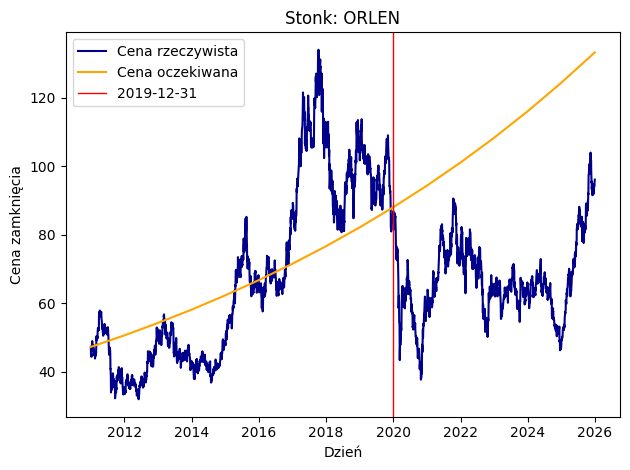

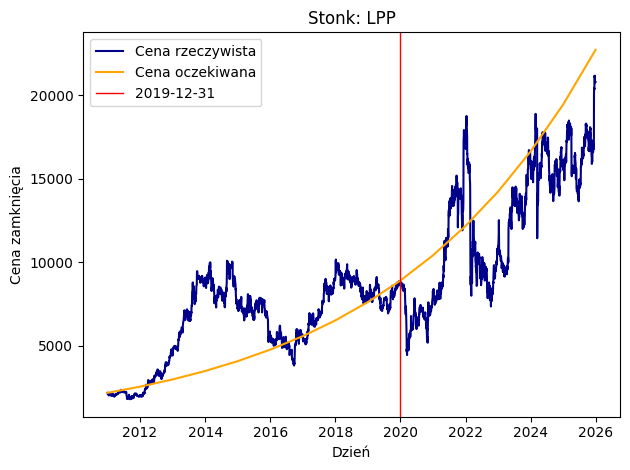

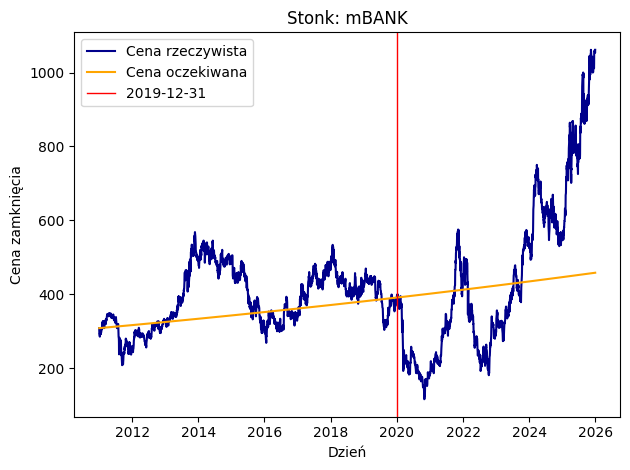

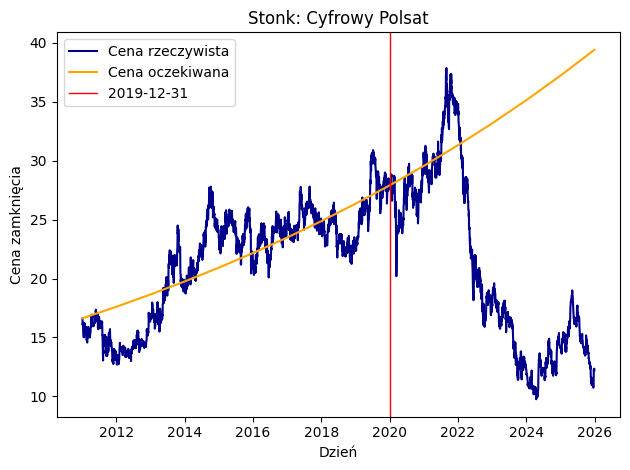

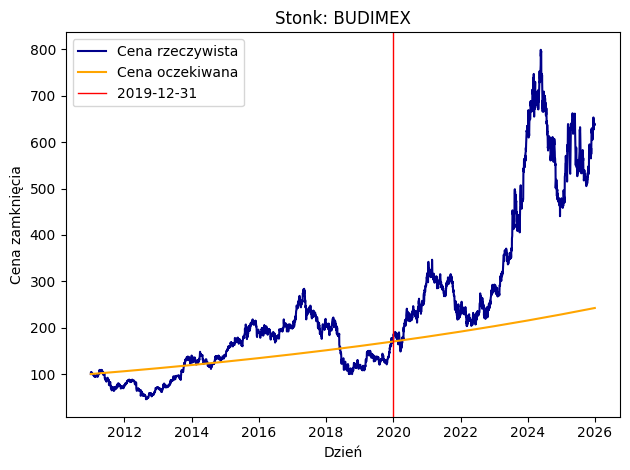

In [28]:
for i in range(len(nazwy)):
    plt.plot(dfs[i]["Date"], dfs[i]["Close"], color="darkblue", label="Cena rzeczywista")
    plt.plot(ceny_oczekiwane[i]["Date"], ceny_oczekiwane[i]["Expected_Close"], color="orange", label="Cena oczekiwana")
    plt.axvline(pd.Timestamp("2019-12-31"), color="red", linestyle="-", linewidth=1, label="2019-12-31")
    plt.xlabel("Dzień")
    plt.ylabel("Cena zamknięcia")
    plt.title(f"Stonk: {nazwy[i]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

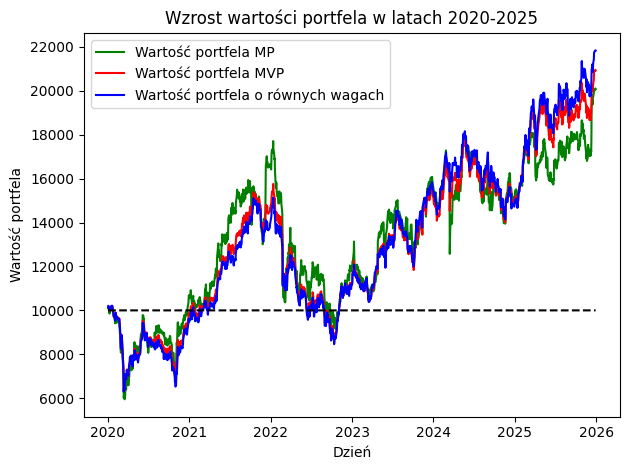

In [29]:
daily_returns = pd.concat(
    [df["Daily_Return"].reset_index(drop=True) for df in dfs_recent],
    axis=1)
daily_returns.columns = [f"Daily_Return_Stonk_{i+1}" for i in range(len(dfs_historical))]
dates = dfs_recent[0]["Date"].reset_index(drop=True)

def get_weighted_returns(budzet, wagi):
    weighted_returns = daily_returns.copy()
    for i in range(len(wagi)):
        column = weighted_returns.columns[i]
        weighted_returns[column] = weighted_returns[column] * wagi[i]
    weighted_returns["Łączny_dzienny_return"] = weighted_returns.sum(axis=1)
    for j in range(len(weighted_returns)):
        budzet.append(budzet[-1] * (1 + weighted_returns["Łączny_dzienny_return"].iloc[j]))
    return budzet[1:]

returny_MP = get_weighted_returns([10000], w_MP)
returny_MVP = get_weighted_returns([10000], w_MVP)
returny_equal = get_weighted_returns([10000], [0.2, 0.2, 0.2, 0.2, 0.2])

plt.plot(dates, returny_MP, color="green", label="Wartość portfela MP")
plt.plot(dates, returny_MVP, color="red", label="Wartość portfela MVP")
plt.plot(dates, returny_equal, color="blue", label="Wartość portfela o równych wagach")
plt.plot(dates, [10000]*len(dates), color="black", linestyle="--")
plt.xlabel("Dzień")
plt.ylabel("Wartość portfela")
plt.title("Wzrost wartości portfela w latach 2020-2025")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print(f"Jeszcze raz: \nStonksy: {nazwy}, \nWagi portfela rynkowego: {w_MP}, \nWagi portfela o minimalnej wariancji: {w_MVP}, \nOczekiwany zwrot portfela rynkowego: {((1+roczne_mu_MP)**6 -1).round(4)}, \nOczekiwany zwrot portfela o minimalnej wariancji: {((1+roczne_mu_MVP)**6 -1).round(4)}, \nRzeczywisty zwrot portfela rynkowego: {((returny_MP[-1]/returny_MP[0]) -1).round(4)}, \nRzeczywisty zwrot portfela o minimalnej wariancji: {((returny_MVP[-1]/returny_MVP[0]) -1).round(4)}, \nRzeczywisty zwrot portfela o równych wagach: {((returny_equal[-1]/returny_equal[0]) -1).round(4 )}.")

Jeszcze raz: 
Stonksy: ['ORLEN', 'LPP', 'mBANK', 'Cyfrowy Polsat', 'BUDIMEX'], 
Wagi portfela rynkowego: [0.189734 0.610011 -0.080470 0.163419 0.117306], 
Wagi portfela o minimalnej wariancji: [0.156196 0.271100 0.158571 0.236729 0.177405], 
Oczekiwany zwrot portfela rynkowego: 1.0956, 
Oczekiwany zwrot portfela o minimalnej wariancji: 0.6404, 
Rzeczywisty zwrot portfela rynkowego: 0.9872, 
Rzeczywisty zwrot portfela o minimalnej wariancji: 1.0618, 
Rzeczywisty zwrot portfela o równych wagach: 1.1489)


## Konkluzja: w sumie to wszystko jedno który portfel się wybierze xde co albo dobrze świadczy o doborze stonksów, albo o danych, albo w sumie to nie wiem co